In [22]:
import numpy as np 
import pandas as pd 
import librosa.display  
import matplotlib.pyplot as plt  
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss

In [9]:
pd.set_option('display.max_columns', None)  #per stampare tutte le colonne
music_data_original = pd.read_csv('Data/features_3_sec.csv') 


colonne=music_data_original.columns.size
print(f'IL DATASET PRESO UN CONSIDERAZIONE HA {colonne} PER OGNI CAMPIONE')
music_data_original.head(5) 

IL DATASET PRESO UN CONSIDERAZIONE HA 60 PER OGNI CAMPIONE


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,tempo,mfcc1_mean,mfcc1_var,mfcc2_mean,mfcc2_var,mfcc3_mean,mfcc3_var,mfcc4_mean,mfcc4_var,mfcc5_mean,mfcc5_var,mfcc6_mean,mfcc6_var,mfcc7_mean,mfcc7_var,mfcc8_mean,mfcc8_var,mfcc9_mean,mfcc9_var,mfcc10_mean,mfcc10_var,mfcc11_mean,mfcc11_var,mfcc12_mean,mfcc12_var,mfcc13_mean,mfcc13_var,mfcc14_mean,mfcc14_var,mfcc15_mean,mfcc15_var,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,1.080790e+06,0.081851,0.000558,-0.000078,0.008354,-0.000068,0.005535,129.199219,-118.627914,2440.286621,125.083626,260.956909,-23.443724,364.081726,41.321484,181.694855,-5.976108,152.963135,20.115141,75.652298,-16.045410,40.227104,17.855198,84.320282,-14.633434,83.437233,10.270527,97.001335,-9.708279,66.669891,10.183875,45.103611,-4.681614,34.169498,8.417439,48.269444,-7.233477,42.770947,-2.853603,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,6.722448e+05,0.087173,0.001030,-0.000099,0.004950,-0.000103,0.004854,123.046875,-125.590706,2038.344238,122.421227,216.774185,-20.718019,231.979767,50.128387,142.700409,-11.333302,139.243118,21.385401,77.817947,-15.960796,97.364029,19.454103,57.948093,-12.465918,68.271523,17.898169,56.222176,-11.732554,54.373909,8.145000,40.662876,-7.717751,30.808521,8.397150,48.784225,-8.300493,68.584824,4.074709,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,7.907127e+05,0.071383,0.000425,-0.000066,0.012476,0.000065,0.004357,123.046875,-132.441940,3798.532227,115.085175,257.321289,-14.811666,192.448074,50.189293,144.166031,-0.680819,128.376892,24.650375,66.371170,-13.506104,89.319336,15.643386,55.253967,-13.216637,120.308784,10.406025,35.757862,-7.991465,47.911613,11.853963,36.569931,-4.677677,40.725075,6.571110,30.686846,-2.424750,50.313499,4.806280,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,9.216524e+05,0.069426,0.000304,-0.000014,0.008318,0.000018,0.005927,123.046875,-118.231087,2508.781006,132.116501,332.650574,-18.758335,109.357529,39.769306,184.693344,-13.260426,144.398224,20.468134,122.516464,-14.563448,68.937332,18.745104,74.748886,-13.755463,73.868576,12.993759,41.549564,-12.648887,58.540478,10.389314,39.102024,-4.362739,60.714748,9.156193,40.411537,-9.889441,44.666325,-1.359111,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,6.102111e+05,0.070095,0.000289,0.000041,0.009634,-0.000106,0.005833,123.046875,-105.968376,2118.919922,134.643646,219.562622,-19.961748,171.878754,40.171753,103.120712,-14.271939,102.651230,18.734617,79.070000,-15.619381,48.510284,19.207966,53.642956,-18.274683,95.300995,14.316693,58.821163,-5.792194,55.030254,17.045437,43.229939,-5.681399,46.515259,5.705521,24.956211,-7.986080,39.816933,2.092937,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


                    Feature  Coefficient
1          chroma_stft_mean     0.276801
4                   rms_var    -0.155230
5    spectral_centroid_mean     0.340959
7   spectral_bandwidth_mean     0.134021
8    spectral_bandwidth_var     0.018897
9              rolloff_mean     0.000361
10              rolloff_var     0.485020
13             harmony_mean    -0.126969
16             perceptr_var    -0.002696
18               mfcc1_mean     0.331029
22               mfcc3_mean    -0.042084
30               mfcc7_mean     0.147484
34               mfcc9_mean     0.134599
40              mfcc12_mean     0.119769
41               mfcc12_var    -0.063388
43               mfcc13_var    -0.015800
52              mfcc18_mean     0.019692


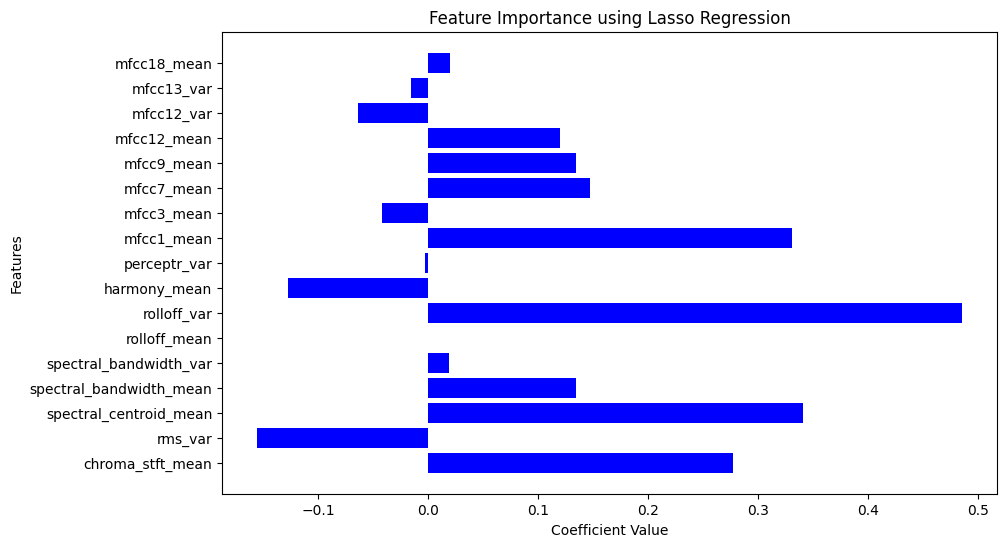

In [15]:
X = music_data_original.drop(columns=['label', 'filename'])
y = music_data_original['label']

# Converti le etichette in numerico
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  # Converte le etichette in numeri

# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Applica la Lasso Regression
lasso = Lasso(alpha=0.1)  # Puoi cambiare il valore di alpha per vedere come influisce sulle feature selezionate
lasso.fit(X_train, y_train)

# Estrai i coefficienti
coefficients = lasso.coef_

# Crea un DataFrame per visualizzare l'importanza delle feature
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

# Seleziona solo le feature con coefficienti non nulli
feature_importance_df = feature_importance_df[feature_importance_df['Coefficient'] != 0]

# Stampa l'importanza delle feature
print(feature_importance_df)

# Visualizza i coefficienti delle feature selezionate
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Coefficient'], color='b')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.title('Feature Importance using Lasso Regression')
plt.show()

In [23]:
# Seleziona le feature importanti
important_features = feature_importance_df['Feature'].values
X_train_selected = X_train[:, [X.columns.get_loc(feature) for feature in important_features]]
X_test_selected = X_test[:, [X.columns.get_loc(feature) for feature in important_features]]

# Addestra un classificatore (Random Forest in questo caso)
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_selected, y_train)

# Fai delle previsioni
y_pred = rf_classifier.predict(X_test_selected)
   # Prevedere le etichette per il set di test
  

    # Calcolare l'accuratezza
    # Calcolare metriche
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

    # Stampare i risultati
print(f'Accuratezza: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'F2-score: {f2:.4f}')
   # print(f'Hinge Loss: {loss}')
print('------------------------------------------------------------')


Accuratezza: 0.8163
Precision: 0.8157
Recall: 0.8163
F1-score: 0.8152
F2-score: 0.8157
------------------------------------------------------------


In [24]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Carica i dati
file_path = 'Data/features_3_sec.csv'  # Assicurati di fornire il percorso corretto
music_data_original = pd.read_csv(file_path)

# Separa le features e la variabile target
X = music_data_original.drop(columns=['label', 'filename'])
y = music_data_original['label']

# Normalizza i dati
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Applica RFE
model = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=model, n_features_to_select=10)  # Seleziona le 10 migliori feature
rfe.fit(X_train, y_train)

# Seleziona le feature importanti
selected_features = X.columns[rfe.support_]

# Addestra un modello con le feature selezionate
X_train_selected = rfe.transform(X_train)
X_test_selected = rfe.transform(X_test)

model.fit(X_train_selected, y_train)

# Valuta il modello
y_pred = model.predict(X_test_selected)

# Visualizza le feature selezionate
print("Selected Features:", selected_features)

KeyboardInterrupt: 